First, import dependencies.

In [1]:
from cartopy import config
from dotenv import load_dotenv
from sodapy import Socrata

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import os 
import pandas as pd

Next, load API secrets from `.env` file.

In [2]:
load_dotenv() 

APP_TOKEN = os.environ['SOCRATA_APP_TOKEN']
APP_SECRET = os.environ['SOCRATA_APP_SECRET']

Create the Socrata client.

In [3]:
client = Socrata("data.seattle.gov", APP_TOKEN)

Let's fetch some data! Default size is 1000 rows.

In [4]:
data = client.get("kzjm-xkqj")
print(data)

[{'address': '110 14th Ave', 'type': 'Aid Response', 'datetime': '2026-02-09T22:26:00.000', 'latitude': '47.601873', 'longitude': '-122.31417', 'report_location': {'type': 'Point', 'coordinates': [-122.31417, 47.601873]}, 'incident_number': 'F260019091', ':@computed_region_ru88_fbhk': '19', ':@computed_region_kuhn_3gp2': '16', ':@computed_region_q256_3sug': '19578'}, {'address': '720 Blanchard St', 'type': 'Aid Response', 'datetime': '2026-02-09T22:26:00.000', 'latitude': '47.616731', 'longitude': '-122.339879', 'report_location': {'type': 'Point', 'coordinates': [-122.339879, 47.616731]}, 'incident_number': 'F260019090', ':@computed_region_ru88_fbhk': '56', ':@computed_region_kuhn_3gp2': '7', ':@computed_region_q256_3sug': '19576'}, {'address': '10113 3rd Ave Nw', 'type': 'Aid Response', 'datetime': '2026-02-09T22:10:00.000', 'latitude': '47.702445', 'longitude': '-122.360743', 'report_location': {'type': 'Point', 'coordinates': [-122.360743, 47.702445]}, 'incident_number': 'F26001908

Sanity check... If I fetch only one record, is it the latest record?

In [5]:
data = client.get("kzjm-xkqj", limit = 100)
print(data)

[{'address': '110 14th Ave', 'type': 'Aid Response', 'datetime': '2026-02-09T22:26:00.000', 'latitude': '47.601873', 'longitude': '-122.31417', 'report_location': {'type': 'Point', 'coordinates': [-122.31417, 47.601873]}, 'incident_number': 'F260019091', ':@computed_region_ru88_fbhk': '19', ':@computed_region_kuhn_3gp2': '16', ':@computed_region_q256_3sug': '19578'}, {'address': '720 Blanchard St', 'type': 'Aid Response', 'datetime': '2026-02-09T22:26:00.000', 'latitude': '47.616731', 'longitude': '-122.339879', 'report_location': {'type': 'Point', 'coordinates': [-122.339879, 47.616731]}, 'incident_number': 'F260019090', ':@computed_region_ru88_fbhk': '56', ':@computed_region_kuhn_3gp2': '7', ':@computed_region_q256_3sug': '19576'}, {'address': '10113 3rd Ave Nw', 'type': 'Aid Response', 'datetime': '2026-02-09T22:10:00.000', 'latitude': '47.702445', 'longitude': '-122.360743', 'report_location': {'type': 'Point', 'coordinates': [-122.360743, 47.702445]}, 'incident_number': 'F26001908

It is... I may have to be careful when fetching large amounts of data in the future using `offset`. If new calls are made while my data is downloading, everything will shift, meaning later chunks might contain missing or duplicate records. This could be perhaps remedied by fetching everything after a given data. Let's get every call since the new year...

Let's see what fields exist in each row...

In [6]:
data[0]

{'address': '110 14th Ave',
 'type': 'Aid Response',
 'datetime': '2026-02-09T22:26:00.000',
 'latitude': '47.601873',
 'longitude': '-122.31417',
 'report_location': {'type': 'Point', 'coordinates': [-122.31417, 47.601873]},
 'incident_number': 'F260019091',
 ':@computed_region_ru88_fbhk': '19',
 ':@computed_region_kuhn_3gp2': '16',
 ':@computed_region_q256_3sug': '19578'}

In [7]:
df = pd.DataFrame.from_records(data)
df

,address,type,datetime,latitude,longitude,report_location,incident_number,:@computed_region_ru88_fbhk,:@computed_region_kuhn_3gp2,:@computed_region_q256_3sug,:@computed_region_2day_rhn5,:@computed_region_cyqu_gs94
0,110 14th Ave,Aid Response,2026-02-09T22:26:00.000,47.601873,-122.31417,"{'type': 'Point', 'coordinates': [-122.31417, ...",F260019091,19,16,19578,NaN,NaN
1,720 Blanchard St,Aid Response,2026-02-09T22:26:00.000,47.616731,-122.339879,"{'type': 'Point', 'coordinates': [-122.339879,...",F260019090,56,7,19576,NaN,NaN
2,10113 3rd Ave Nw,Aid Response,2026-02-09T22:10:00.000,47.702445,-122.360743,"{'type': 'Point', 'coordinates': [-122.360743,...",F260019088,23,32,18229,NaN,NaN
3,7516 32nd Ave Nw,Crisis Center,2026-02-09T22:03:00.000,47.683202,-122.398301,"{'type': 'Point', 'coordinates': [-122.398301,...",F260019085,3,23,18798,135,NaN
4,808 Howell St,Aid Response,2026-02-09T22:02:00.000,47.614127,-122.334009,"{'type': 'Point', 'coordinates': [-122.334009,...",F260019084,56,31,18081,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
95,14100 LINDEN AVE N,Auto Fire Alarm,2026-02-09T15:37:00.000,47.73104,-122.347764,"{'type': 'Point', 'coordinates': [-122.347764,...",F260018947,6,33,19582,116,1
96,14002 LINDEN AVE N,Aid Response,2026-02-09T15:37:00.000,47.730569,-122.347758,"{'type': 'Point', 'coordinates': [-122.347758,...",F260018946,6,33,19582,116,1
97,300 10th Ave,Activated CO Detector,2026-02-09T15:36:00.000,47.60436,-122.319411,"{'type': 'Point', 'coordinates': [-122.319411,...",F260018945,19,16,19578,NaN,NaN
98,1902 S Main St,Aid Response,2026-02-09T15:26:00.000,47.599999,-122.307634,"{'type': 'Point', 'coordinates': [-122.307634,...",F260018943,28,17,17919,NaN,NaN


Can we iterate over the rows and plot the points on a map?

In [8]:
float(df["latitude"].min())

47.499758

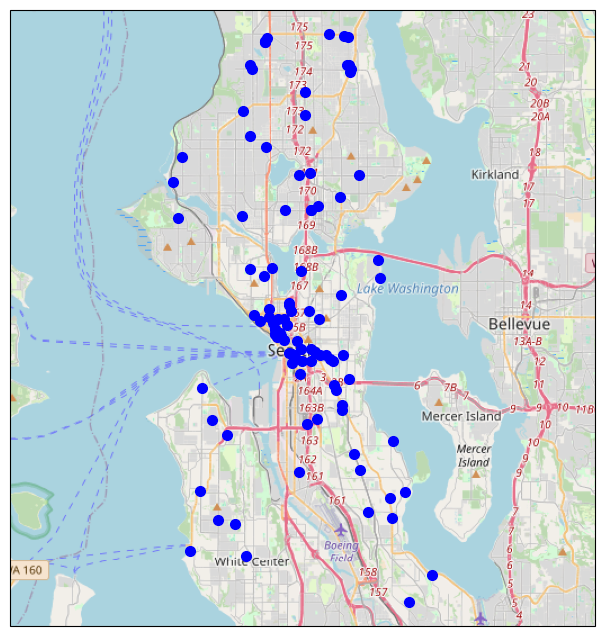

In [9]:
padding = 0.01
lon_min, lon_max = float(df["longitude"].min()) + padding * 10, float(df["longitude"].max()) - padding * 10
lat_min, lat_max = float(df["latitude"].min()) - padding, float(df["latitude"].max()) + padding

osm_tiles = cimgt.OSM()
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': osm_tiles.crs})
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.add_image(osm_tiles, 11)

for datum in data:
    ax.plot(
        float(datum['longitude']), 
        float(datum['latitude']), 
        'bo', markersize=7, transform=ccrs.Geodetic()
    )

plt.show()

Neat! Now, SFD live has "richer" data than we have. They actually know which units were assigned to which event. Would it be possible for us to create a map of events that a specific unit responds to? And perhaps plot the route most likely taken between each event? To get an estimated sense of how far each unit drives every hour? That would be an interesting question to ask of the available data and one that could perhaps be useful for shift scheduling?

I'll look for the source of the response unit data!